# 05 - Visualization
Spatial predictions, error maps, RMSE over time, training history.

**Inputs (from Notebooks 03 and 04):** `predictions.npy`, `y_test.npy`, `training_history.json`

**Outputs:** `obs_vs_pred.png`, `error_maps.png`, `rmse_over_time.png`, `training_history.png`

> **Note on latitude extent:** `bbox_model` lat range is 10-20 N, but plots use 7-20 N
> for geographic context (South China Sea / WPS coastline framing).
>
> Cartopy is used to overlay land masses so the Philippine archipelago and
> surrounding coastlines are visible on all spatial plots.

In [20]:
!pip install -q matplotlib scikit-learn cartopy

In [21]:
# CELL 2 — imports + CONFIG

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import json, os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

CONFIG = {
    'bbox_regional': {'lat_min': 0,  'lat_max': 30,  'lon_min': 110, 'lon_max': 140},
    'bbox_model':    {'lat_min': 10, 'lat_max': 20,  'lon_min': 114, 'lon_max': 120},
    'date_full':  {'start': '2014-01-01', 'end': '2024-12-31'},
    'date_model': {'start': '2017-01-01', 'end': '2024-12-31'},  # synced with 03
    'data_dir': '/content/drive/MyDrive/fishing_project/',
    'files': {
        'physics_w_nc':    'cmems_mod_glo_phy_my_0.083deg_P1M-m_1779636039565.nc',
        'physics_ht_nc':   'cmems_mod_glo_phy_my_0.083deg_P1M-m_1779635380319.nc',
        'bgc_src_nc':      'cmems_mod_glo_bgc_my_0.25deg_P1M-m_1779635372583.nc',
        'physics_nc':      'physics_raw_region.nc',
        'bgc_nc':          'bgc_raw_region.nc',
        'ais_parquet':     'ais_raw_region.parquet',
        'ais_csv_gz':      'ais_raw_region.csv.gz',
        'ais_gridded_nc':  'ais_fishing_effort_gridded.nc',
        'preprocessed_nc': 'preprocessed_features.nc',
        'norm_stats_json': 'norm_stats.json',
        'model_pt':        'convlstm_model.pt',
        'best_model_pt':   'best_model.pt',
        'weights_npz':     'convlstm_weights.npz',
        'X_test_npy':      'X_test.npy',
        'y_test_npy':      'y_test.npy',
        'history_json':    'training_history.json',
        'summary_json':    'data_summary.json',
        'predictions_npy': 'predictions.npy',
        'eval_csv':        'evaluation_results.csv',
    },
    'ais_use_cols':          ['date', 'cell_ll_lat', 'cell_ll_lon', 'fishing_hours'],
    'physics_surface_depth': 0.49,
    'bgc_depth_range':       (0.51, 5.14),
    'norm_method':           'minmax',
    'resample_freq':         '1ME',
    'seq_len':      3,
    'pred_len':     1,
    'n_channels':   7,
    'train_frac':   0.70,
    'val_frac':     0.15,
    'epochs':       100,
    'batch_size':   4,
    'patience':     15,
    'f1_threshold': 0.15,
}

DATA_DIR = CONFIG['data_dir']
f        = CONFIG['files']

print(f'Cartopy : {cartopy.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cartopy : 0.25.0


In [22]:
# CELL 3 — load predictions and test labels
y_test = np.load(DATA_DIR + f['y_test_npy'])
preds  = np.load(DATA_DIR + f['predictions_npy'])

print(f'y_test shape : {y_test.shape}')   # Expected: (N, H, W, 1)
print(f'preds  shape : {preds.shape}')    # Expected: (N, H, W, 1)

bm = CONFIG['bbox_model']
LON_MIN,      LON_MAX      = bm['lon_min'], bm['lon_max']
LAT_MIN_DATA, LAT_MAX_DATA = bm['lat_min'], bm['lat_max']
# Pad southern extent for geographic context (Philippines coastline visible at ~7 N)
LAT_MIN_VIZ,  LAT_MAX_VIZ  = 7, LAT_MAX_DATA

print(f'Visualization extent : lat {LAT_MIN_VIZ}-{LAT_MAX_VIZ} N, '
      f'lon {LON_MIN}-{LON_MAX} E')

y_test shape : (15, 41, 25, 1)
preds  shape : (15, 41, 25, 1)
Visualization extent : lat 7-20 N, lon 114-120 E


In [25]:
# CELL 4 — shared colormap + cartopy helper

CMAP_FISHING = LinearSegmentedColormap.from_list(
    'fishing',
    ['#000033', '#0000FF', '#FF00FF', '#FF0000'],
)

PROJ    = ccrs.PlateCarree()   # data and display both in PlateCarree
EXTENT  = [LON_MIN, LON_MAX, LAT_MIN_VIZ, LAT_MAX_VIZ]


def make_geo_ax(fig, pos):
    """
    Create a cartopy GeoAxes at subplot position `pos` with:
      - land filled in light grey (Natural Earth 10 m resolution)
      - coastlines drawn at 10 m resolution
      - lat / lon gridlines and labels
    Returns the axes.
    """
    ax = fig.add_subplot(*pos, projection=PROJ)
    ax.set_extent(EXTENT, crs=PROJ)

    # Land overlay — drawn on top of the imshow data
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '10m',
        facecolor='#d9d9d9', edgecolor='none', zorder=2,
    ))
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'coastline', '10m',
        facecolor='none', edgecolor='#555555', linewidth=0.5, zorder=3,
    ))

    gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                      color='white', alpha=0.6, linestyle='--', zorder=4)
    gl.top_labels   = False
    gl.right_labels = False
    gl.xformatter   = LONGITUDE_FORMATTER
    gl.yformatter   = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}
    gl.xlocator = mticker.FixedLocator(range(LON_MIN, LON_MAX + 1, 2))
    gl.ylocator = mticker.FixedLocator(range(LAT_MIN_VIZ, LAT_MAX_VIZ + 1, 2))
    return ax


def geo_imshow(ax, arr, cmap, vmin, vmax):
    """
    imshow on a GeoAxes using data extent and PlateCarree transform.
    `arr` is a 2-D array with axes [lat, lon] (origin='lower').
    """
    return ax.imshow(
        arr,
        origin='lower',
        extent=[LON_MIN, LON_MAX, LAT_MIN_DATA, LAT_MAX_DATA],
        transform=PROJ,
        cmap=cmap, vmin=vmin, vmax=vmax,
        aspect='auto',
        zorder=1,
    )


print('Colormap and geo helper defined.')

Colormap and geo helper defined.


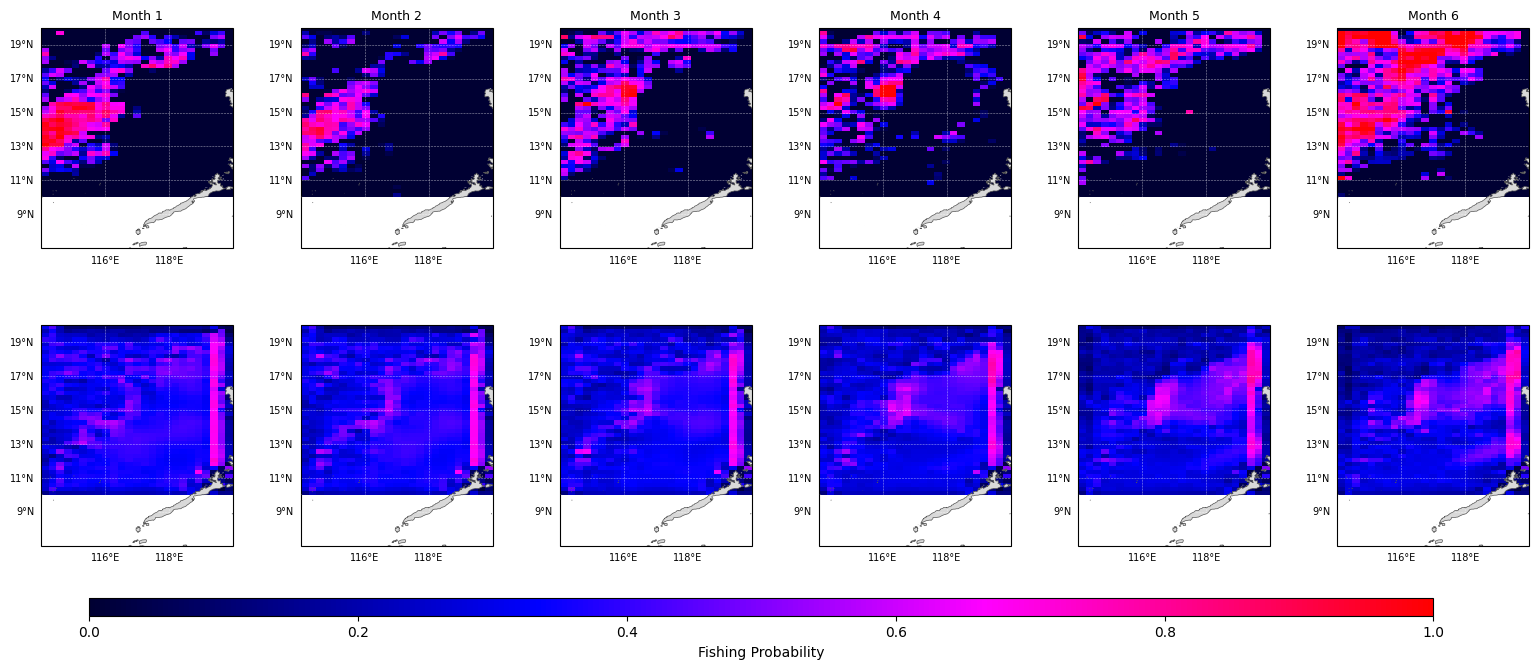

Saved -> obs_vs_pred.png


In [26]:
# CELL 5 — Figure 1: observed vs predicted (up to 6 test samples)

n_samples = min(6, len(y_test))
fig = plt.figure(figsize=(3.2 * n_samples, 7))

for i in range(n_samples):
    # Observed row
    ax_obs = make_geo_ax(fig, (2, n_samples, i + 1))
    im     = geo_imshow(ax_obs, y_test[i, :, :, 0], CMAP_FISHING, 0, 1)
    ax_obs.set_title(f'Month {i+1}', fontsize=9)
    if i == 0:
        ax_obs.set_ylabel('Observed', fontsize=9)

    # Predicted row
    ax_pred = make_geo_ax(fig, (2, n_samples, n_samples + i + 1))
    im      = geo_imshow(ax_pred, preds[i, :, :, 0], CMAP_FISHING, 0, 1)
    if i == 0:
        ax_pred.set_ylabel('Predicted', fontsize=9)

fig.subplots_adjust(bottom=0.14, hspace=0.35, wspace=0.35)
cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.025])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Fishing Probability')

plt.savefig(DATA_DIR + 'obs_vs_pred.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> obs_vs_pred.png')

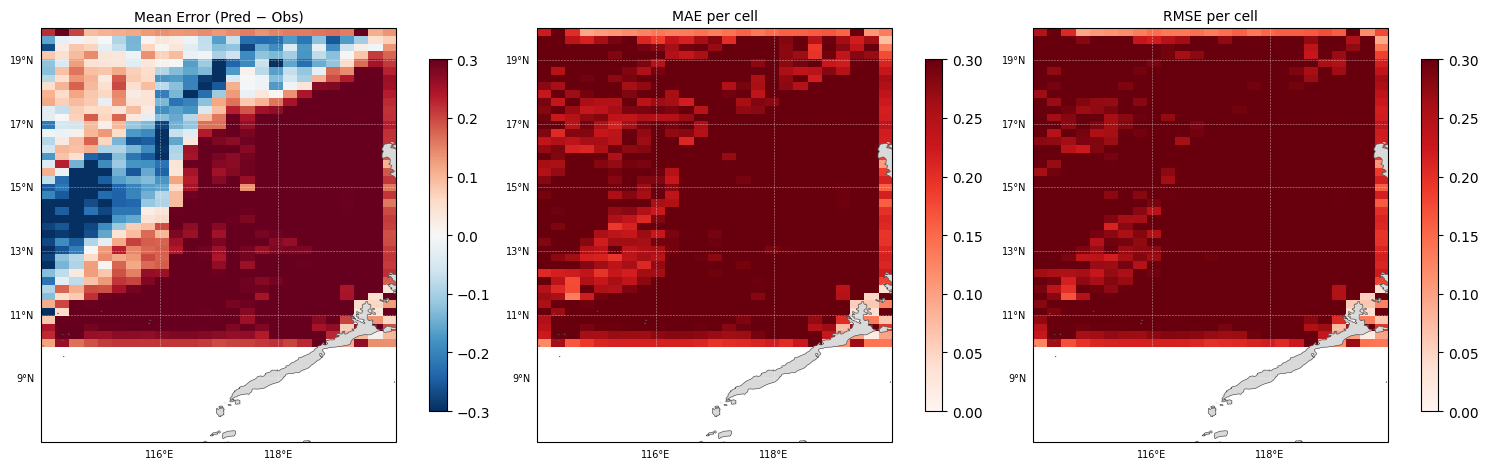

Saved -> error_maps.png


In [27]:
# CELL 6 — Figure 2: spatial error maps averaged across all test samples

err_arr  = preds - y_test                         # (N, H, W, 1)
mean_err = err_arr.mean(axis=0)[:, :, 0]          # positive = over-predict
mae_map  = np.abs(err_arr).mean(axis=0)[:, :, 0]
rmse_map = np.sqrt((err_arr**2).mean(axis=0))[:, :, 0]

panels = [
    (mean_err, 'RdBu_r', -0.3,  0.3, 'Mean Error (Pred − Obs)'),
    (mae_map,  'Reds',    0.0,  0.3, 'MAE per cell'),
    (rmse_map, 'Reds',    0.0,  0.3, 'RMSE per cell'),
]

fig = plt.figure(figsize=(15, 4.8))

for idx, (arr, cmap_name, vmin, vmax, title) in enumerate(panels, start=1):
    ax = make_geo_ax(fig, (1, 3, idx))
    im = geo_imshow(ax, arr, cmap_name, vmin, vmax)
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, shrink=0.85)

plt.tight_layout()
plt.savefig(DATA_DIR + 'error_maps.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> error_maps.png')

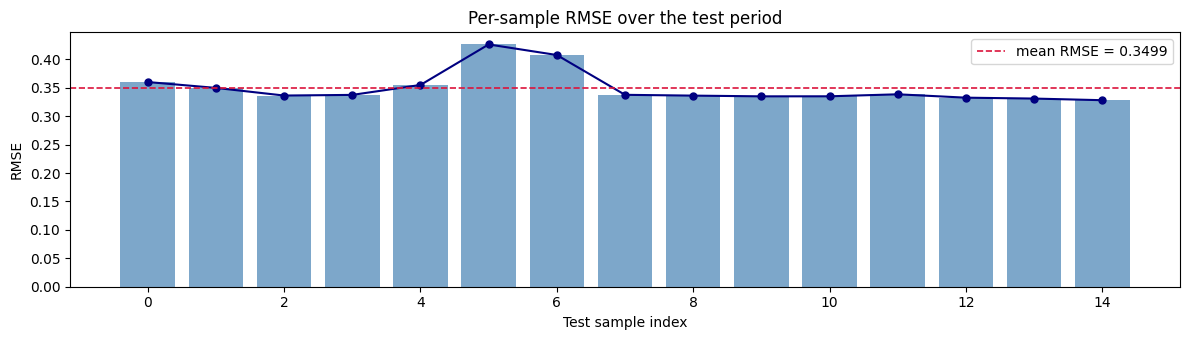

Saved -> rmse_over_time.png


In [28]:
# CELL 7 — Figure 3: per-sample RMSE over the test period
from sklearn.metrics import mean_squared_error

rmse_list = [
    float(np.sqrt(mean_squared_error(
        np.nan_to_num(y_test[i].flatten(), nan=0.0),
        np.nan_to_num(preds[i].flatten(),  nan=0.0),
    )))
    for i in range(len(y_test))
]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(len(rmse_list)), rmse_list, alpha=0.7, color='steelblue')
ax.plot(range(len(rmse_list)), rmse_list,
        color='navy', linewidth=1.5, marker='o', markersize=5)
ax.axhline(float(np.mean(rmse_list)), color='crimson', linewidth=1.2,
           linestyle='--', label=f'mean RMSE = {np.mean(rmse_list):.4f}')
ax.set_xlabel('Test sample index')
ax.set_ylabel('RMSE')
ax.set_title('Per-sample RMSE over the test period')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR + 'rmse_over_time.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> rmse_over_time.png')

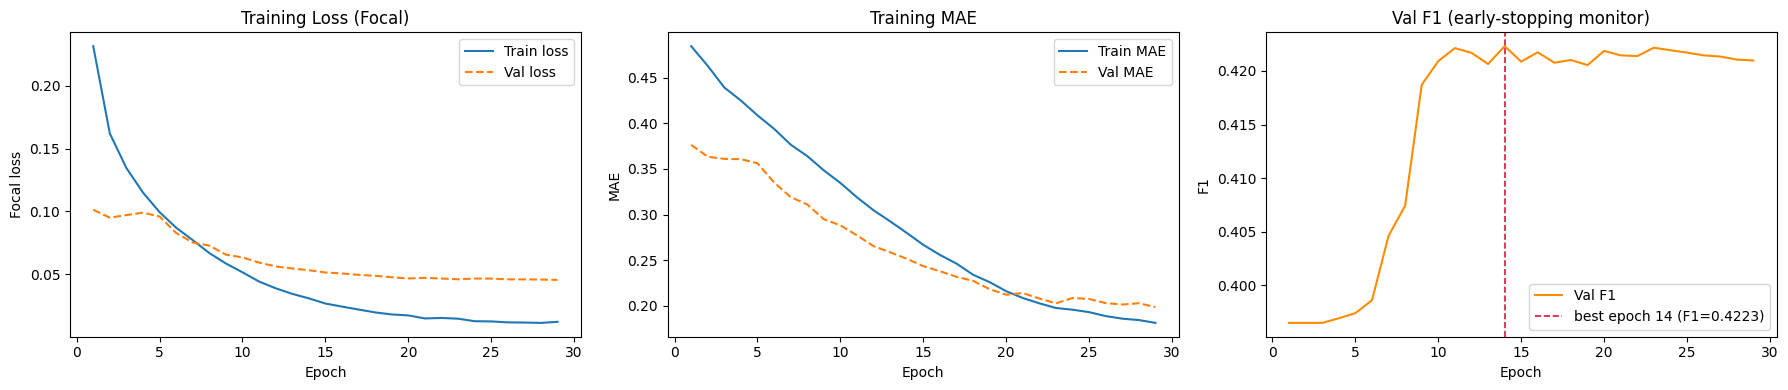

Saved -> training_history.png
Notebook 05 complete.


In [29]:
# CELL 8 — Figure 4: training history curves
#
# Notebook 03 saves: loss, mae, val_loss, val_mae, val_f1
# Three panels: Focal Loss, MAE, Val F1 (new — 03 monitors this instead of val_loss)

history_path = DATA_DIR + f['history_json']
if not os.path.exists(history_path):
    print(f'training_history.json not found at {history_path}.')
    print('Run 03_buildntraintorch.ipynb first.')
else:
    with open(history_path) as fh:
        history_dict = json.load(fh)

    loss_tr  = history_dict.get('loss', [])
    loss_vl  = history_dict.get('val_loss', [])
    mae_tr   = history_dict.get('mae', [])
    mae_vl   = history_dict.get('val_mae', [])
    val_f1   = history_dict.get('val_f1', [])
    epochs   = list(range(1, len(loss_tr) + 1))

    has_f1 = len(val_f1) > 0
    n_cols = 3 if has_f1 else 2

    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4))

    # Panel 1 — Focal Loss
    axes[0].plot(epochs, loss_tr, label='Train loss')
    axes[0].plot(epochs[:len(loss_vl)], loss_vl, linestyle='--', label='Val loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Focal loss')
    axes[0].set_title('Training Loss (Focal)')
    axes[0].legend()

    # Panel 2 — MAE
    axes[1].plot(epochs, mae_tr, label='Train MAE')
    axes[1].plot(epochs[:len(mae_vl)], mae_vl, linestyle='--', label='Val MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title('Training MAE')
    axes[1].legend()

    # Panel 3 — Val F1 (early-stopping monitor in 03)
    if has_f1:
        best_ep  = int(np.argmax(val_f1)) + 1
        best_f1v = float(np.max(val_f1))
        axes[2].plot(epochs[:len(val_f1)], val_f1, color='darkorange', label='Val F1')
        axes[2].axvline(best_ep, color='crimson', linewidth=1.2, linestyle='--',
                        label=f'best epoch {best_ep} (F1={best_f1v:.4f})')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('F1')
        axes[2].set_title('Val F1 (early-stopping monitor)')
        axes[2].legend()

    plt.tight_layout()
    plt.savefig(DATA_DIR + 'training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved -> training_history.png')
    print('Notebook 05 complete.')